In [1]:
# Core
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
!pip install statsmodels
# Classical models
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Feature-based model
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Optional Bayesian model
# pip install pymc arviz
#import pymc as pm
#import arviz as az

# Optional N-BEATS model
# pip install "u8darts[torch]"
#from darts import TimeSeries
#from darts.models import NBEATSModel


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
#Load the dataset
df = pd.read_csv("time_series_60min_singleindex.csv",
    usecols=["utc_timestamp", "DE_load_actual_entsoe_transparency"],
    parse_dates=["utc_timestamp"]
)

In [2]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Data columns (total 2 columns):
 #   Column                              Non-Null Count  Dtype              
---  ------                              --------------  -----              
 0   utc_timestamp                       50401 non-null  datetime64[ns, UTC]
 1   DE_load_actual_entsoe_transparency  50400 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(1)
memory usage: 787.6 KB


,DE_load_actual_entsoe_transparency
count,50400.000000
mean,55492.468552
std,10015.431042
min,31307.000000
25%,47106.000000
50%,55092.000000
75%,64309.250000
max,77549.000000


In [3]:
#Clean and prepare
df = df.rename(columns={
    "utc_timestamp": "date",
    "DE_load_actual_entsoe_transparency": "load_mw"
})

df = df.set_index("date").sort_index()

load = df["load_mw"].astype(float)
load = load[load.notna()]
load = load["2015-01-01":]

In [4]:
# Create Daily + Weekly Data
daily = load.resample("D").mean()
weekly = load.resample("W").mean() / 1000
weekly = weekly.interpolate("time")
weekly.name = "load_gw"


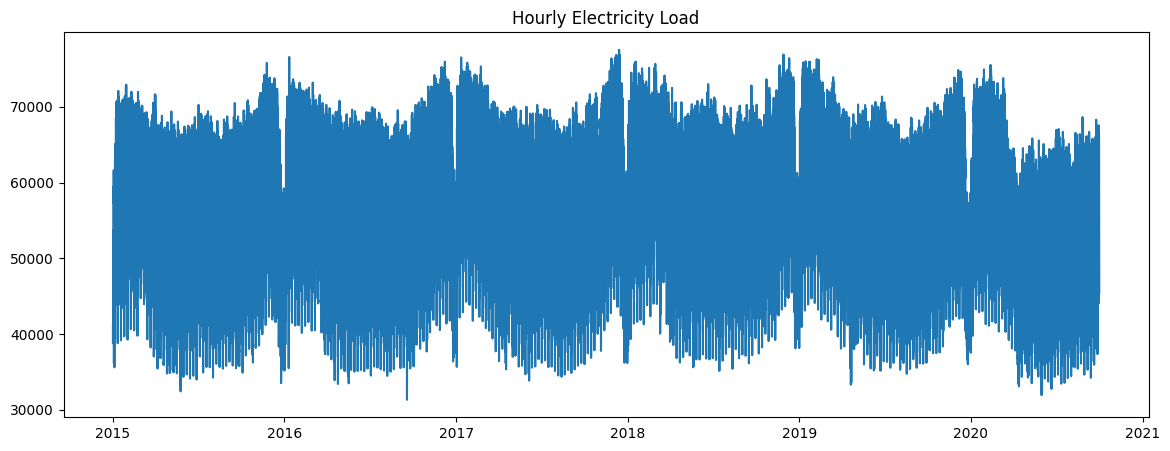

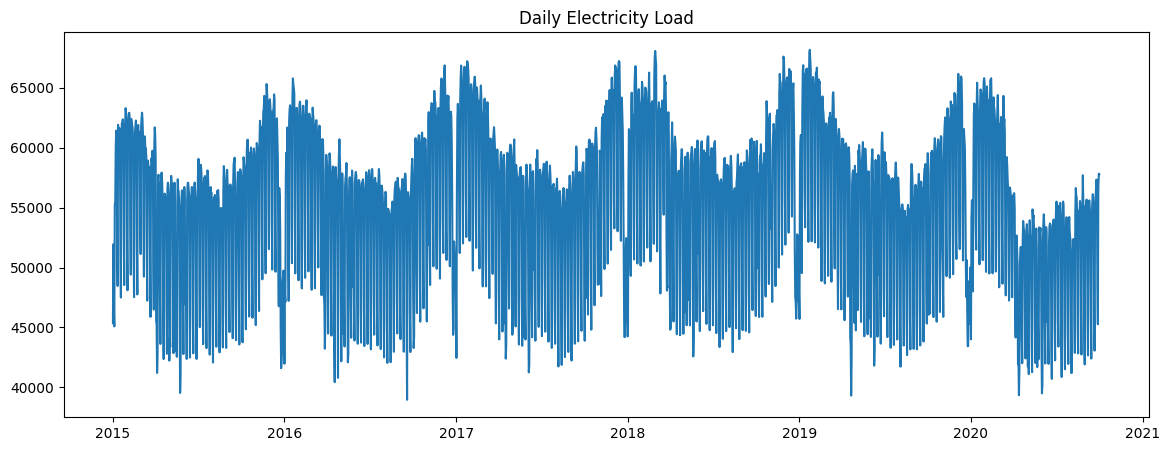

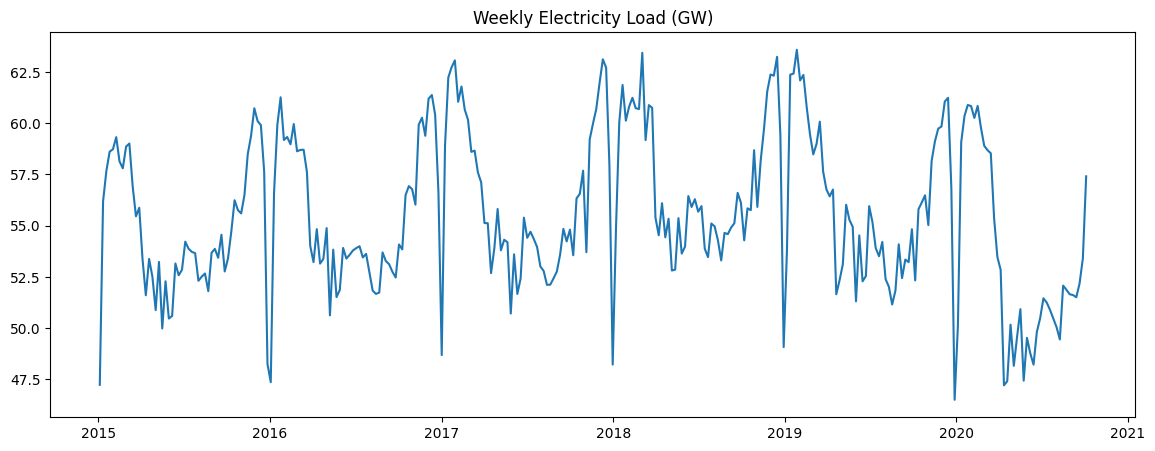

In [5]:
# Plot ALL time scales
plt.figure(figsize=(14,5))
plt.plot(load)
plt.title("Hourly Electricity Load")
plt.show()

plt.figure(figsize=(14,5))
plt.plot(daily)
plt.title("Daily Electricity Load")
plt.show()

plt.figure(figsize=(14,5))
plt.plot(weekly)
plt.title("Weekly Electricity Load (GW)")
plt.show()

In [6]:
# Train-test split
test_weeks = 104

train = weekly.iloc[:-test_weeks]
test = weekly.iloc[-test_weeks:]

print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

2015-01-04 00:00:00+00:00 2018-10-07 00:00:00+00:00
2018-10-14 00:00:00+00:00 2020-10-04 00:00:00+00:00


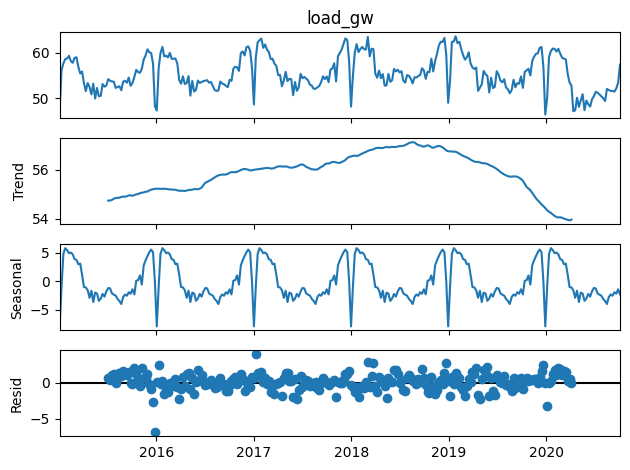

In [7]:

# BASIC EDA
# Trend + Seasonality plot
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(weekly, period=52)
decomposition.plot()
plt.show()


In [8]:
# ADF Test (stationarity)
from statsmodels.tsa.stattools import adfuller

result = adfuller(weekly)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.047471855678484
p-value: 0.001181349734015439


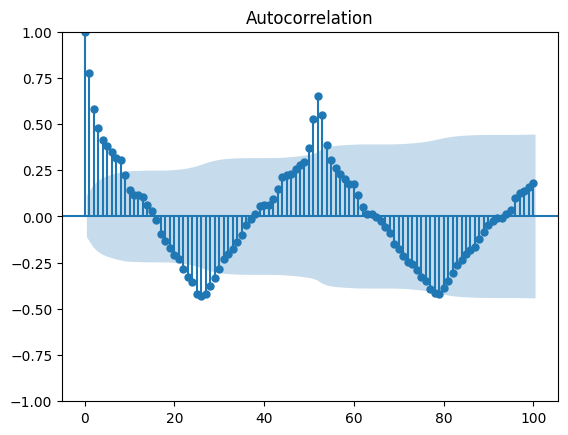

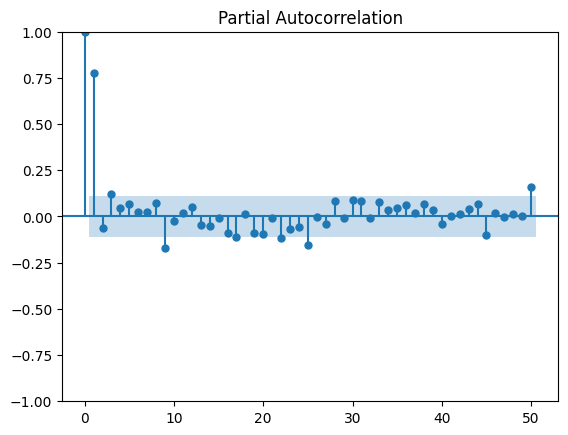

In [9]:
# ACF + PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(weekly, lags=100)
plt.show()

plot_pacf(weekly, lags=50)
plt.show()

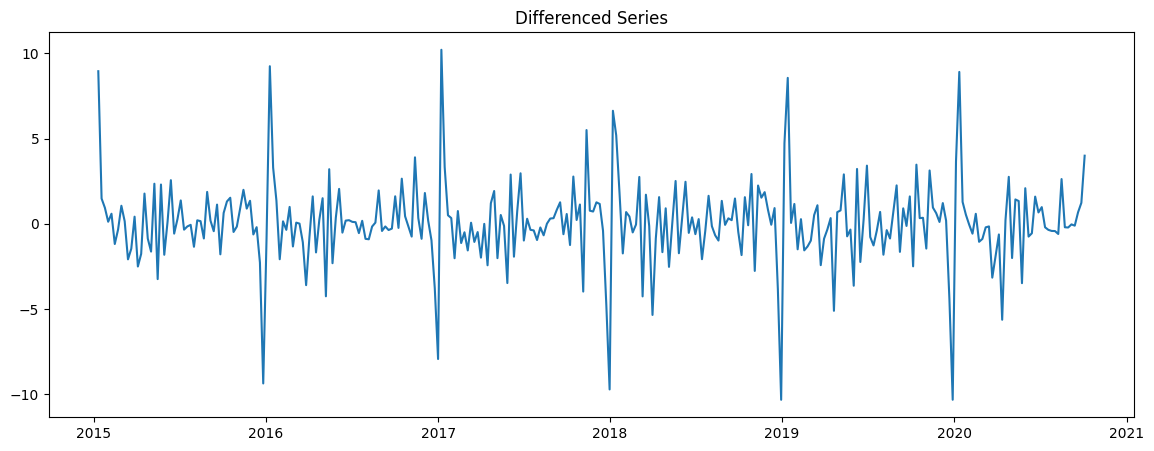

In [10]:
# Differencing
weekly_diff = weekly.diff().dropna()

plt.figure(figsize=(14,5))
plt.plot(weekly_diff)
plt.title("Differenced Series")
plt.show()

In [11]:
# BENCHMARK MODELS
# Set horizon
h = len(test)

In [12]:
# Mean Forecast
mean_forecast = pd.Series(train.mean(), index=test.index)
# Naive Forecast
naive_forecast = pd.Series(train.iloc[-1], index=test.index)
# Seasonal Naive
seasonal_naive = []

history = train.copy()

for date in test.index:
    seasonal_date = date - pd.DateOffset(weeks=52)

    if seasonal_date in history.index:
        value = history.loc[seasonal_date]
    else:
        value = history.iloc[-52]

    seasonal_naive.append(value)

    # update history (walk-forward style)
    history.loc[date] = test.loc[date]

seasonal_naive_forecast = pd.Series(seasonal_naive, index=test.index)

In [13]:
# Evaluation Function
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd # Ensure pandas is imported for pd.Series
import numpy as np  # Ensure numpy is imported for np.sqrt, np.mean, np.abs

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mase(y_true, y_pred, y_train, seasonality=52):
    """
    Mean absolute scaled error.
    Uses seasonal naive in-sample errors as the scaling denominator.
    """
    naive_errors = np.abs(y_train.iloc[seasonality:].values - y_train.iloc[:-seasonality].values)
    scale = naive_errors.mean()
    return np.mean(np.abs(y_true - y_pred)) / scale

def evaluate_forecast(name, y_true, y_pred, y_train):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)

    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train),
        "Bias": np.mean(y_pred - y_true),
    }

# Removed redundant results initialization and appends from this cell.

In [14]:
results = []

# Drift Forecast
drift_slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)

drift_forecast = pd.Series(
    train.iloc[-1] + drift_slope * np.arange(1, h + 1),
    index=test.index
)

benchmark_forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal naive": seasonal_naive_forecast,
    "Drift": drift_forecast,
}

for name, pred in benchmark_forecasts.items():
    results.append(evaluate_forecast(name, test, pred, train))

In [15]:
# Drift Forecast
drift = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)

drift_forecast = pd.Series(
    train.iloc[-1] + drift * np.arange(1, h + 1),
    index=test.index
)

In [16]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("MASE")

print(results_df)

            model       MAE      RMSE      MASE      Bias
2  Seasonal naive  2.063028  2.671877  1.541484  1.440722
1           Naive  3.783203  4.459109  2.826789 -0.882480
0            Mean  3.788833  4.397300  2.830996  0.481006
3           Drift  4.339891  5.117957  3.242743  1.006802


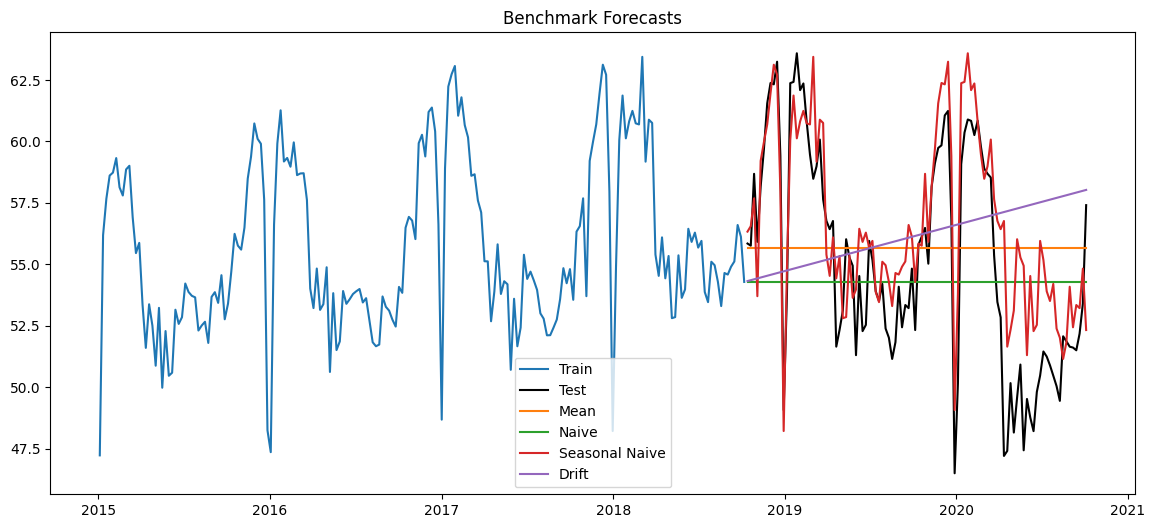

In [17]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", color="black")

plt.plot(test.index, mean_forecast, label="Mean")
plt.plot(test.index, naive_forecast, label="Naive")
plt.plot(test.index, seasonal_naive_forecast, label="Seasonal Naive")
plt.plot(test.index, drift_forecast, label="Drift")

plt.title("Benchmark Forecasts")
plt.legend()
plt.show()

In [18]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

p = range(0, 7)
d = range(0, 3)
q = range(0, 7)

pdq = list(itertools.product(p, d, q))

results_aic = []

best_aic = float("inf")
best_order = None

for order in pdq:

    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=(0,0,0,0),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fit = model.fit(disp=False)

        results_aic.append([order, fit.aic])

        if fit.aic < best_aic:
            best_aic = fit.aic
            best_order = order

    except:
        continue

print("Best Order:", best_order)
print("Best AIC:", best_aic)

aic_table = pd.DataFrame(results_aic,
                         columns=["Order", "AIC"])

aic_table.sort_values("AIC").head(10)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Best Order: (1, 1, 6)
Best AIC: 839.2617357915274


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Order,AIC
34,"(1, 1, 6)",839.261736
83,"(3, 2, 6)",840.012935
118,"(5, 1, 6)",840.957298
125,"(5, 2, 6)",841.074039
104,"(4, 2, 6)",841.283448
146,"(6, 2, 6)",841.621782
139,"(6, 1, 6)",841.874297
55,"(2, 1, 6)",842.578661
76,"(3, 1, 6)",844.129338
41,"(1, 2, 6)",844.403595


In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(
    train,
    order=best_order,
    seasonal_order=(1,1,1,52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_fit = sarima.fit(disp=False)

print(sarima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                              load_gw   No. Observations:                  197
Model:             SARIMAX(1, 1, 6)x(1, 1, [1], 52)   Log Likelihood                -140.852
Date:                              Fri, 03 Jul 2026   AIC                            303.704
Time:                                      12:51:50   BIC                            330.573
Sample:                                  01-04-2015   HQIC                           314.512
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0082      0.012     -0.712      0.477      -0.031       0.014
ar.L1          0.38

In [20]:
h = len(test)

forecast = sarima_fit.get_forecast(steps=h)

sarima_mean = forecast.predicted_mean

sarima_ci95 = forecast.conf_int(alpha=0.05)

sarima_mean.index = test.index
sarima_ci95.index = test.index

In [21]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(
    mean_squared_error(test, sarima_mean)
)

print("SARIMA RMSE =", rmse)

SARIMA RMSE = 2.7296228656581576


<Figure size 1000x500 with 0 Axes>

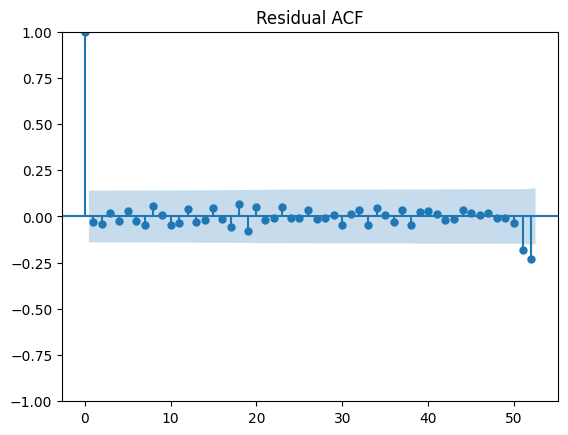

In [22]:
from statsmodels.graphics.tsaplots import plot_acf

residuals = sarima_fit.resid

plt.figure(figsize=(10,5))
plot_acf(residuals.dropna(), lags=52)
plt.title("Residual ACF")
plt.show()

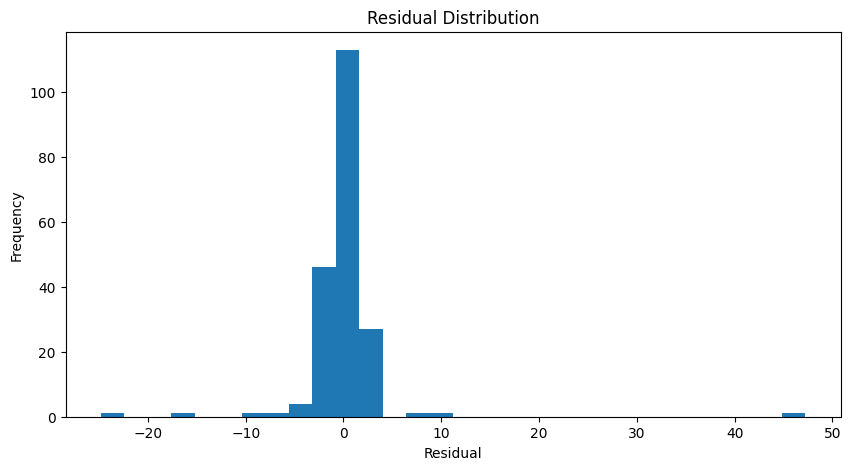

In [23]:
plt.figure(figsize=(10,5))

plt.hist(
    residuals.dropna(),
    bins=30
)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

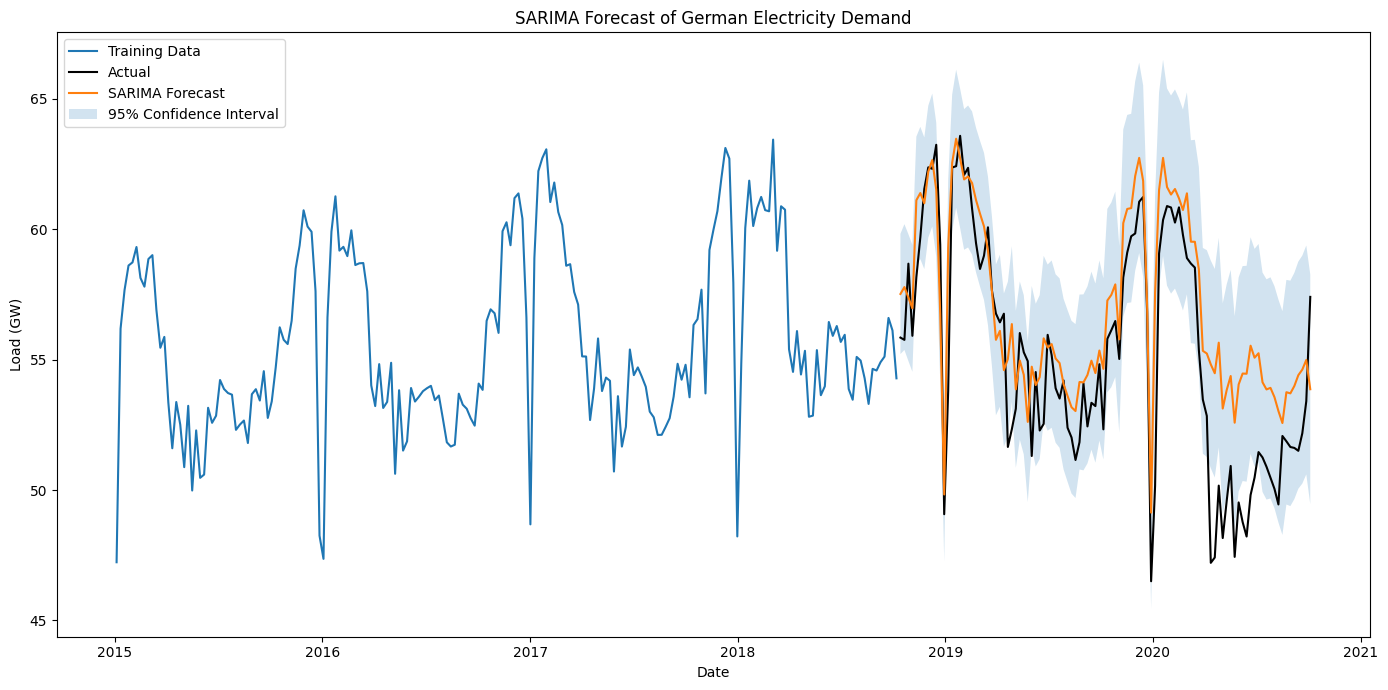

In [24]:
plt.figure(figsize=(14,7))

plt.plot(
    train.index,
    train,
    label="Training Data"
)

plt.plot(
    test.index,
    test,
    color="black",
    label="Actual"
)

plt.plot(
    test.index,
    sarima_mean,
    label="SARIMA Forecast"
)

plt.fill_between(
    test.index,
    sarima_ci95.iloc[:,0],
    sarima_ci95.iloc[:,1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(
    "SARIMA Forecast of German Electricity Demand"
)

plt.xlabel("Date")
plt.ylabel("Load (GW)")

plt.legend()

plt.tight_layout()

plt.show()

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mase(y_true, y_pred, y_train, seasonality=52):
    naive_errors = np.abs(
        y_train.iloc[seasonality:].values -
        y_train.iloc[:-seasonality].values
    )
    scale = naive_errors.mean()
    return np.mean(np.abs(y_true - y_pred)) / scale

def evaluate(name, y_true, y_pred, y_train):
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train),
        "Bias": np.mean(y_pred - y_true),
    }

In [26]:
results.append(
    evaluate(
        "SARIMA",
        test,
        sarima_mean,
        train
    )
)

results_df = pd.DataFrame(results)

print(results_df.sort_values("MASE"))

            model       MAE      RMSE      MASE      Bias
2  Seasonal naive  2.063028  2.671877  1.541484  1.440722
4          SARIMA  2.133525  2.729623  1.594158  1.727384
1           Naive  3.783203  4.459109  2.826789 -0.882480
0            Mean  3.788833  4.397300  2.830996  0.481006
3           Drift  4.339891  5.117957  3.242743  1.006802


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


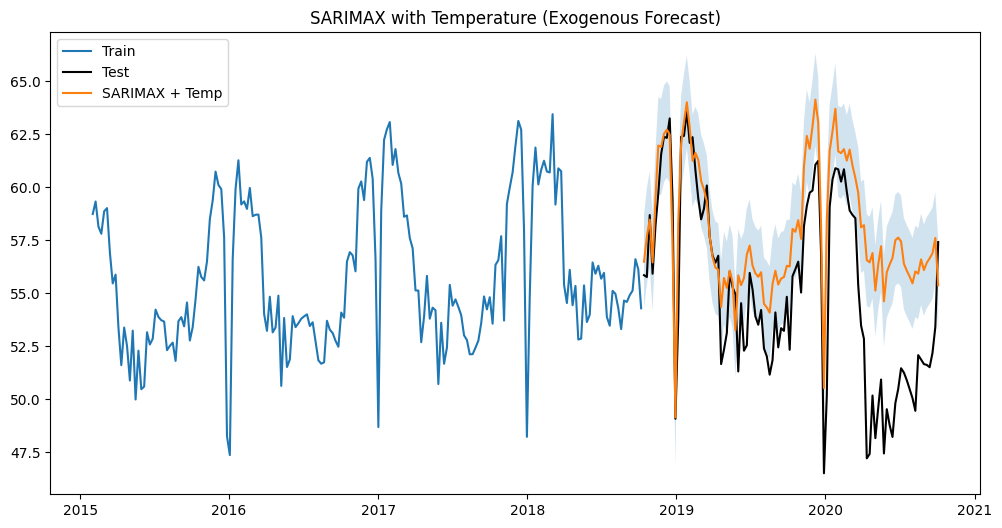

In [27]:

# ============================================================
# PART 4 — SARIMAX with Exogenous Temperature Variables
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ------------------------------------------------------------
# 1. Get temperature data (Berlin)
# ------------------------------------------------------------

def get_open_meteo_temperature(
    latitude=52.52,
    longitude=13.41,
    start_date="2015-01-01",
    end_date="2020-12-31",
):
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean",
        "timezone": "Europe/Berlin",
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()["daily"]

    temp = pd.DataFrame({
        "date": pd.to_datetime(data["time"]),
        "temperature_2m_mean": data["temperature_2m_mean"],
    })

    temp = temp.set_index("date")
    return temp


# ------------------------------------------------------------
# 2. FIX TIMEZONE ISSUES (VERY IMPORTANT)
# ------------------------------------------------------------

load.index = pd.to_datetime(load.index).tz_localize(None)

# ------------------------------------------------------------
# 3. Get temperature data
# ------------------------------------------------------------

temp_daily = get_open_meteo_temperature(
    start_date=str(load.index.min().date()),
    end_date=str(load.index.max().date()),
)

temp_daily.index = pd.to_datetime(temp_daily.index).tz_localize("Europe/Berlin")

# ------------------------------------------------------------
# 4. Weekly temperature features
# ------------------------------------------------------------

# Convert temp_daily to UTC first to ensure alignment with weekly.index
temp_daily_utc = temp_daily.tz_convert("UTC")

temp_weekly = pd.DataFrame(index=weekly.index)

temp_weekly["temp_mean"] = temp_daily_utc["temperature_2m_mean"].resample("W").mean()
temp_weekly["temp_min"] = temp_daily_utc["temperature_2m_mean"].resample("W").min()
temp_weekly["temp_max"] = temp_daily_utc["temperature_2m_mean"].resample("W").max()

base_heat = 15.5
base_cool = 22.0

temp_weekly["heating_degree"] = np.maximum(
    base_heat - temp_daily_utc["temperature_2m_mean"], 0
).resample("W").sum()

temp_weekly["cooling_degree"] = np.maximum(
    temp_daily_utc["temperature_2m_mean"] - base_cool, 0
).resample("W").sum()


# ------------------------------------------------------------
# 5. Merge with electricity load
# ------------------------------------------------------------

# weekly features (you must define this first)
weekly_features = pd.DataFrame(index=weekly.index)

weekly_features["lag_1"] = weekly.shift(1)
weekly_features["lag_2"] = weekly.shift(2)
weekly_features["lag_4"] = weekly.shift(4)

weekly_features["roll_mean_4"] = weekly.rolling(4).mean()
weekly_features["roll_std_4"] = weekly.rolling(4).std()

# merge everything
feature_df = pd.DataFrame({"load_gw": weekly})

feature_df = feature_df.join(weekly_features)
feature_df = feature_df.join(temp_weekly)

feature_df = feature_df.interpolate("time").dropna()

feature_df.head()
# ------------------------------------------------------------
# 6. Train-test split
# ------------------------------------------------------------

y = feature_df["load_gw"]

X = feature_df[[
    "temp_mean",
    "heating_degree",
    "cooling_degree"
]]

test_weeks = 104

y_train = y.iloc[:-test_weeks]
y_test = y.iloc[-test_weeks:]

X_train = X.iloc[:-test_weeks]
X_test = X.iloc[-test_weeks:]


# ------------------------------------------------------------
# 7. SARIMAX with exogenous variables
# ------------------------------------------------------------

sarimax_x = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarimax_x_fit = sarimax_x.fit(disp=False)

sarimax_x_fc = sarimax_x_fit.get_forecast(
    steps=len(y_test),
    exog=X_test
)

sarimax_x_mean = sarimax_x_fc.predicted_mean
sarimax_x_ci = sarimax_x_fc.conf_int()

sarimax_x_mean.index = y_test.index
sarimax_x_ci.index = y_test.index


# ------------------------------------------------------------
# 8. Evaluation
# ------------------------------------------------------------

results.append(
    evaluate_forecast("SARIMAX + Temperature", y_test, sarimax_x_mean, y_train)
)


# ------------------------------------------------------------
# 9. Plot results
# ------------------------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Test", color="black")

plt.plot(y_test.index, sarimax_x_mean, label="SARIMAX + Temp")

plt.fill_between(
    y_test.index,
    sarimax_x_ci.iloc[:, 0],
    sarimax_x_ci.iloc[:, 1],
    alpha=0.2
)

plt.title("SARIMAX with Temperature (Exogenous Forecast)")
plt.legend()
plt.show()

            model          MAE         RMSE      MASE         Bias
1   Random Forest  1915.494673  2575.136374  1.431979   278.055173
0  SARIMAX + Temp  2754.630894  3487.724372  2.059298  2472.023119


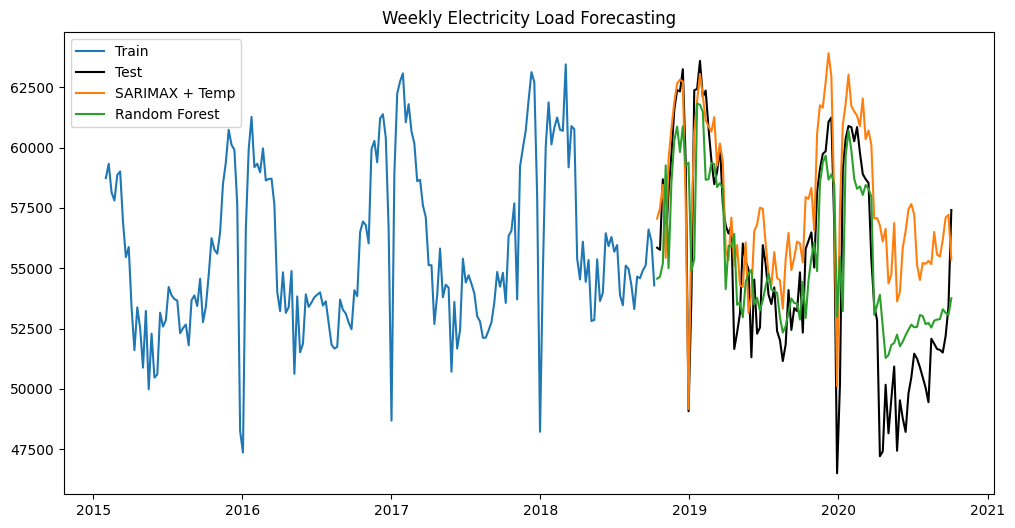

In [28]:
# ============================================================
# COMPLETE PIPELINE — ELECTRICITY LOAD FORECASTING
# Parts 1–5 (Clean + Debugged Version)
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ============================================================
# 0. LOAD DATA (ASSUMED PROVIDED)
# ============================================================

load.index = pd.to_datetime(load.index).tz_localize(None)

weekly = load.resample("W").mean()
weekly = weekly.asfreq("W")
weekly.name = "load_gw"


# ============================================================
# 1. EVALUATION FUNCTIONS
# ============================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mase(y_true, y_pred, y_train, seasonality=52):
    naive = np.abs(y_train[seasonality:].values - y_train[:-seasonality].values)
    scale = naive.mean()
    return np.mean(np.abs(y_true - y_pred)) / scale

def evaluate_forecast(name, y_true, y_pred, y_train):
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred, index=y_true.index)

    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train),
        "Bias": np.mean(y_pred - y_true),
    }

results = []


# ============================================================
# 2. TEMPERATURE DATA (SAFE API VERSION)
# ============================================================

def get_temperature(start, end):
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": 52.52,
        "longitude": 13.41,
        "start_date": start,
        "end_date": end,
        "daily": "temperature_2m_mean",
        "timezone": "Europe/Berlin"
    }

    r = requests.get(url, params=params, timeout=30)

    # FIX: API safety check (prevents JSONDecodeError)
    if r.status_code != 200:
        raise ValueError(f"API failed: {r.status_code}, {r.text[:100]}")

    data = r.json()["daily"]

    df = pd.DataFrame({
        "date": pd.to_datetime(data["time"]),
        "temp": data["temperature_2m_mean"]
    }).set_index("date")

    return df


temp_daily = get_temperature(
    str(weekly.index.min().date()),
    str(weekly.index.max().date())
)


# ============================================================
# 3. WEEKLY TEMPERATURE FEATURES
# ============================================================

temp_weekly = pd.DataFrame(index=weekly.index)

temp_weekly["temp_mean"] = temp_daily["temp"].resample("W").mean()
temp_weekly["temp_min"]  = temp_daily["temp"].resample("W").min()
temp_weekly["temp_max"]  = temp_daily["temp"].resample("W").max()

base_heat = 15.5
base_cool = 22.0

temp_weekly["heating_degree"] = (
    np.maximum(base_heat - temp_daily["temp"], 0).resample("W").sum()
)

temp_weekly["cooling_degree"] = (
    np.maximum(temp_daily["temp"] - base_cool, 0).resample("W").sum()
)


# ============================================================
# 4. LAG + ROLLING FEATURES (FIXED)
# ============================================================

weekly_features = pd.DataFrame(index=weekly.index)

weekly_features["lag_1"] = weekly.shift(1)
weekly_features["lag_2"] = weekly.shift(2)
weekly_features["lag_4"] = weekly.shift(4)

weekly_features["roll_mean_4"] = weekly.shift(1).rolling(4).mean()
weekly_features["roll_std_4"]  = weekly.shift(1).rolling(4).std()


# ============================================================
# 5. MERGE ALL FEATURES
# ============================================================

feature_df = pd.concat(
    [weekly, weekly_features, temp_weekly],
    axis=1
)

feature_df = feature_df.dropna()

y = feature_df["load_gw"]

X_temp = feature_df[["temp_mean", "heating_degree", "cooling_degree"]]
X_full = feature_df.drop(columns=["load_gw"])


# ============================================================
# SPLIT
# ============================================================

test_weeks = 104

y_train = y[:-test_weeks]
y_test  = y[-test_weeks:]


# ============================================================
# PART 4 — SARIMAX (EXOG TEMPERATURE)
# ============================================================

X_train = X_temp[:-test_weeks]
X_test  = X_temp[-test_weeks:]

sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax.fit(disp=False)

sarimax_fc = sarimax_fit.get_forecast(steps=len(y_test), exog=X_test)

sarimax_mean = sarimax_fc.predicted_mean
sarimax_mean.index = y_test.index

results.append(evaluate_forecast("SARIMAX + Temp", y_test, sarimax_mean, y_train))


# ============================================================
# PART 5 — RANDOM FOREST MODEL
# ============================================================

X_train = X_full[:-test_weeks]
X_test  = X_full[-test_weeks:]

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = pd.Series(rf.predict(X_test), index=y_test.index)

results.append(evaluate_forecast("Random Forest", y_test, rf_pred, y_train))


# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results).sort_values("RMSE")
print(results_df)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Test", color="black")

plt.plot(y_test.index, sarimax_mean, label="SARIMAX + Temp")
plt.plot(y_test.index, rf_pred, label="Random Forest")

plt.legend()
plt.title("Weekly Electricity Load Forecasting")
plt.show()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 168, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0076 - val_loss: 1.6456e-04
Epoch 2/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0026 - val_loss: 3.5321e-05
Epoch 3/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0021 - val_loss: 2.0215e-05
Epoch 4/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0016 - val_loss: 3.0269e-05
Epoch 5/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0012 - val_loss: 1.2948e-04
Epoch 6/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 9.0220e-04 - val_loss: 5.8491e-05
Epoch 7/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 7.1560e-04 - val_loss: 8.8178e-06
Epoch 8/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 5.5402e-04 - val_loss: 1.4465e-05
Epoch 9/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 4.6160e-04 - val_loss: 7.6113e-06
Epoch 10/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 3.9977e-04 - val_loss: 7.6033e-05
548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step

LSTM Performance
---------

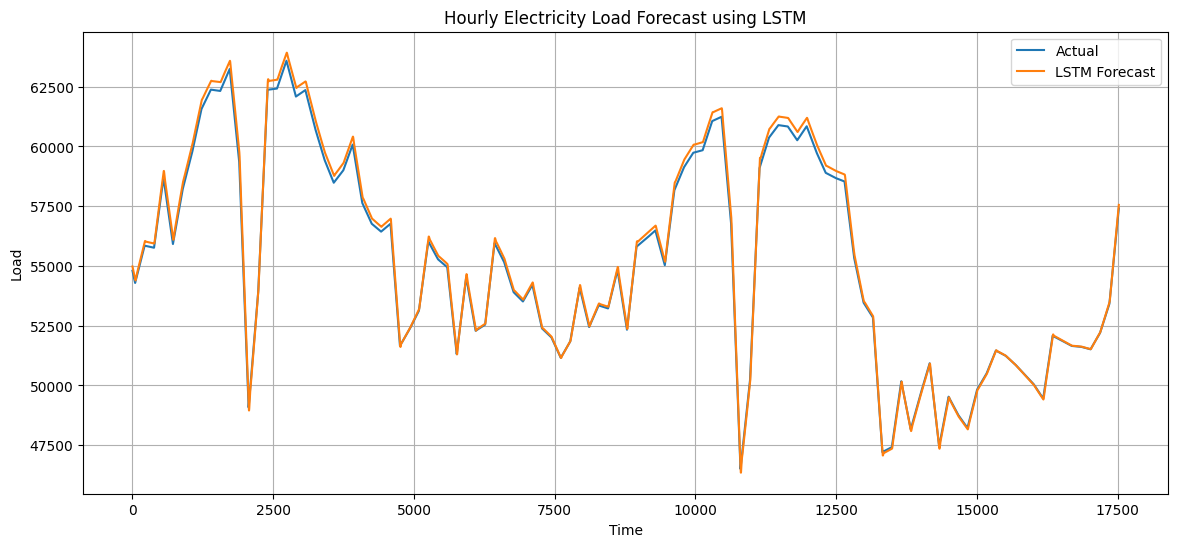

In [32]:

# PART 6 — LSTM MODEL FOR HOURLY ELECTRICITY FORECASTING


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


# ============================================================
# 1. LOAD HOURLY DATA
# ============================================================

# ASSUMPTION: you already have hourly load series
# Example: load_hourly = df["load"]
# ------------------------------------------------------------
# CREATE HOURLY SERIES FROM WEEKLY DATA (SAFE FIX)
# ------------------------------------------------------------

load_hourly = weekly.resample("H").interpolate("time")
load_hourly.name = "load"
load_hourly = load_hourly.copy()
load_hourly.index = pd.to_datetime(load_hourly.index)
load_hourly = load_hourly.sort_index()
load_hourly = load_hourly.dropna()

values = load_hourly.values.reshape(-1, 1)


# ============================================================
# 2. SCALE DATA (IMPORTANT FOR LSTM)
# ============================================================

scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)


# ============================================================
# 3. CREATE SEQUENCES
# ============================================================

def create_sequences(data, window=24*7):  # 1 week history
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 24 * 7  # weekly pattern

X, y = create_sequences(scaled, window)


# ============================================================
# 4. TRAIN-TEST SPLIT (LAST 2 YEARS = 48 HOURS? NO → 2 YEARS HOURLY)
# ============================================================

test_size = 24 * 365 * 2   # 2 years hourly forecast

X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]


# ============================================================
# 5. BUILD LSTM MODEL
# ============================================================

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

model.summary()


# ============================================================
# 6. TRAIN MODEL
# ============================================================

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


# ============================================================
# 7. PREDICTIONS
# ============================================================

pred_scaled = model.predict(X_test)

pred = scaler.inverse_transform(pred_scaled)
y_test_inv = scaler.inverse_transform(y_test)


# ============================================================
# 8. EVALUATION METRICS
# ============================================================

rmse = np.sqrt(mean_squared_error(y_test_inv, pred))
mae = mean_absolute_error(y_test_inv, pred)

print("\nLSTM Performance")
print("----------------")
print(f"RMSE: {rmse:.3f}")
print(f"MAE : {mae:.3f}")


# ============================================================
# 9. PLOT RESULTS
# ============================================================

plt.figure(figsize=(14,6))

plt.plot(y_test_inv, label="Actual")
plt.plot(pred, label="LSTM Forecast")

plt.title("Hourly Electricity Load Forecast using LSTM")
plt.xlabel("Time")
plt.ylabel("Load")
plt.legend()
plt.grid(True)

plt.show()